# GPQR Tutoral

Gaussian process quantile regression (GPQR) estimates quantile function using Gaussian process regression.

In this tutorial, we estimate multiple quantile levels for data with heteroscadastic noise. To avoid quantile crossing, multitask center-gap architecture with informative prior is used.

In [ ]:
from IPython import get_ipython
from matplotlib.backends.backend_svg import FigureCanvasSVG
from matplotlib_inline.backend_inline import set_matplotlib_formats
import matplotlib.pyplot as plt


def print_svg_no_metadata(fig):
    canvas = FigureCanvasSVG(fig)
    return canvas.print_svg(metadata={})


svg_formatter = get_ipython().display_formatter.formatters["image/svg+xml"]
svg_formatter.for_type(plt.Figure, print_svg_no_metadata)

set_matplotlib_formats("svg")

plt.rcParams["svg.hashsalt"] = ""
plt.rcParams["svg.fonttype"] = "path"

In [ ]:
import torch
import gpytorch

from gpytorch_qr.mtgpqr_cg import (
    MultitaskCenterGapQuantileGP,
    CenterGapLmcVariationalStrategy,
    MultitaskCenterGapALDLikelihood,
)

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x_range = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
x = x_range.repeat(5, 1)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9]).to(device)
true_quantiles = mean(x_range) + std(x_range) * torch.distributions.Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

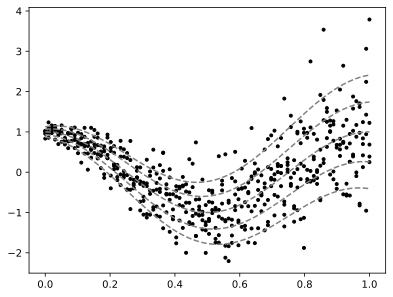

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

## Prior mean for central quantile

In [ ]:
class PriorMean(gpytorch.means.Mean):
    def forward(self, x):
        return mean(x).squeeze()

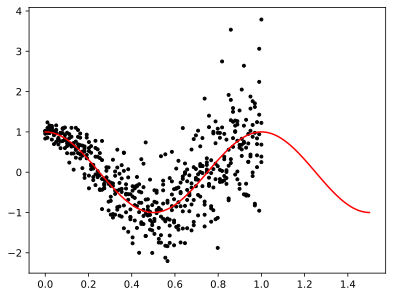

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_pred.cpu(), PriorMean()(x_pred).detach().cpu(), c="r")
plt.show()

## Define model and likelihood

In [ ]:
class MyGP(MultitaskCenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
        num_lower_latents,
    ):
        N, D = inducing_points.size()
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = CenterGapLmcVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles=num_quantiles,
            num_latents=num_latents,
            num_lower_quantiles=num_lower_quantiles,
            num_lower_latents=num_lower_latents,
        )

        center_mean = PriorMean()
        gap_mean = gpytorch.means.ConstantMean(
            batch_shape=torch.Size([num_latents - 1])
        )
        covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                ard_num_dims=D, batch_shape=torch.Size([num_latents])
            ),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(variational_strategy, center_mean, gap_mean, covar_module)


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
central_q_index = 2
num_latents = 3
gp = MyGP(inducing_points, len(q), central_q_index, num_latents, num_latents // 2).to(
    device
)
likelihood = MultitaskCenterGapALDLikelihood(q, central_q_index).to(device)

## Train

In [ ]:
gp.train()
likelihood.train()
mll = gpytorch.mlls.VariationalELBO(likelihood, gp, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

for _ in range(1000):
    output = gp(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

## Evaluate

In [ ]:
gp.eval()
with torch.no_grad():
    quantiles = gp.mean_quantiles(x_pred, central_q_index).detach()

## Plot result

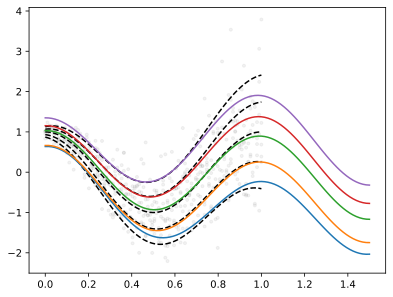

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="gray", marker=".", alpha=0.1)
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="k")
plt.plot(x_pred.cpu(), quantiles.cpu())
plt.show()